# Notebook 04: RAG Pipeline

**CRISP-DM Phase: Modeling**

This notebook builds and tests the complete RAG pipeline:
1. Create vector store with document embeddings
2. Build retrieval pipeline
3. Integrate with LLM for answer generation
4. Test with sample queries
5. Experiment with different retrieval parameters (top-K)

In [ ]:
# Standard imports
import sys
import json
import time
from pathlib import Path

# Add project root to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

# Project imports
from src.config import (
    GROUND_TRUTH_DIR, METRICS_DIR, FIGURES_DIR,
    TOP_K_VALUES, print_config
)
from src.data_loader import load_all_documents
from src.chunker import chunk_all_documents
from src.embeddings import EmbeddingModel
from src.vector_store import VectorStore, create_experiment_store
from src.llm_client import get_llm_client
from src.rag_pipeline import RAGPipeline

# Visualization
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')

# Print configuration
print_config()

RAG Q&A System Configuration
  LLM Provider:      ollama
  Ollama Model:      llama3.2:3b
  Ollama URL:        http://localhost:11434
  Embedding Model:   bge (BAAI/bge-small-en-v1.5)
  Chunking:          recursive (size=1000, overlap=200)
  Top-K:             5
  Similarity Thresh: 0.5
  Project Root:      /home/umukesh/Desktop/dl


## 4.1 Build Vector Store

Load documents, chunk them, generate embeddings, and store in ChromaDB.

In [2]:
# Load and chunk documents
documents = load_all_documents()
chunks = chunk_all_documents(documents, strategy='recursive', chunk_size=1000, chunk_overlap=200)
print(f"Total chunks: {len(chunks)}")

# Initialize embedding model
embedding_model = EmbeddingModel('bge')
print(f"Embedding model: {embedding_model.get_info()}")

2026-04-09 12:26:13,386 - rag_qa_system - INFO - Loaded PDF with PyPDF2: CCAC-AR2026-2-our-changing-climate-final.pdf (33 pages)


2026-04-09 12:26:13,393 - rag_qa_system - INFO -   Loaded: CCAC-AR2026-2-our-changing-climate-final.pdf (11504 words)


2026-04-09 12:26:18,975 - rag_qa_system - INFO - Loaded PDF with PyPDF2: Energy-in-Ireland-2025.pdf (238 pages)


2026-04-09 12:26:19,006 - rag_qa_system - INFO -   Loaded: Energy-in-Ireland-2025.pdf (60874 words)


2026-04-09 12:26:19,015 - rag_qa_system - INFO - Loaded text file: carbon_capture_and_storage.txt (43957 chars)


...

2026-04-09 12:26:30,195 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/BAAI/bge-small-en-v1.5/resolve/main/1_Pooling/config.json "HTTP/1.1 307 Temporary Redirect"


2026-04-09 12:26:30,220 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/BAAI/bge-small-en-v1.5/5c38ec7c405ec4b44b94cc5a9bb96e735b38267a/1_Pooling%2Fconfig.json "HTTP/1.1 200 OK"


2026-04-09 12:26:30,496 - httpx - INFO - HTTP Request: GET https://huggingface.co/api/models/BAAI/bge-small-en-v1.5 "HTTP/1.1 200 OK"


2026-04-09 12:26:30,685 - rag_qa_system - INFO - Loaded embedding model 'bge' (dims=384, backend=sentence_transformers, load_time=7.76s)


Embedding model: {'model_name': 'bge', 'model_id': 'BAAI/bge-small-en-v1.5', 'dimensions': 384, 'backend': 'sentence_transformers', 'load_time_seconds': 7.76265287399292}


In [3]:
# Create vector store and add chunks
vector_store = create_experiment_store(
    experiment_name='rag_main_bge_recursive',
    chunks=chunks,
    embedding_model=embedding_model,
)

print(f"\nVector store info: {vector_store.get_collection_info()}")

2026-04-09 12:26:30,820 - rag_qa_system - INFO - Vector store initialized: 'rag_main_bge_recursive' (0 existing documents)


2026-04-09 12:26:30,873 - rag_qa_system - INFO - Cleared collection 'rag_main_bge_recursive'


2026-04-09 12:26:30,874 - rag_qa_system - INFO - Embedding 2096 chunks with bge...


Batches:   0%|          | 0/66 [00:00<?, ?it/s]

2026-04-09 12:26:48,728 - rag_qa_system - INFO - Embedding completed in 17.85s


2026-04-09 12:26:51,446 - rag_qa_system - INFO - Added 2096 chunks to collection 'rag_main_bge_recursive' (total: 2096)



Vector store info: {'collection_name': 'rag_main_bge_recursive', 'document_count': 2096, 'persist_dir': '/home/umukesh/Desktop/dl/vector_store'}


## 4.2 Initialize RAG Pipeline

In [4]:
# Initialize LLM client
llm_client = get_llm_client()
print(f"LLM client: {llm_client.get_info()}")

# Create RAG pipeline
rag_pipeline = RAGPipeline(
    vector_store=vector_store,
    embedding_model=embedding_model,
    llm_client=llm_client,
    top_k=5,
)

print(f"\nPipeline info: {json.dumps(rag_pipeline.get_pipeline_info(), indent=2, default=str)}")

2026-04-09 12:26:51,490 - httpx - INFO - HTTP Request: GET http://localhost:11434/api/tags "HTTP/1.1 200 OK"


2026-04-09 12:26:51,491 - rag_qa_system - INFO - Ollama client initialized with model: llama3.2:3b


2026-04-09 12:26:51,492 - rag_qa_system - INFO - RAG Pipeline initialized: store='rag_main_bge_recursive', embedding='bge', llm='llama3.2:3b', top_k=5


LLM client: {'provider': 'ollama', 'model': 'llama3.2:3b', 'base_url': 'http://localhost:11434'}

Pipeline info: {
  "vector_store": {
    "collection_name": "rag_main_bge_recursive",
    "document_count": 2096,
    "persist_dir": "/home/umukesh/Desktop/dl/vector_store"
  },
  "embedding_model": {
    "model_name": "bge",
    "model_id": "BAAI/bge-small-en-v1.5",
    "dimensions": 384,
    "backend": "sentence_transformers",
    "load_time_seconds": 7.76265287399292
  },
  "llm": {
    "provider": "ollama",
    "model": "llama3.2:3b",
    "base_url": "http://localhost:11434"
  },
  "top_k": 5,
  "similarity_threshold": 0.5,
  "queries_processed": 0
}


## 4.3 Test with Sample Queries

In [5]:
# Test with individual queries
test_questions = [
    "What is Ireland's 2030 greenhouse gas emissions reduction target?",
    "How many electric vehicles does Ireland target by 2030?",
    "What is the European Green Deal?",
    "What percentage of electricity does Ireland get from wind?",
    "What is carbon capture and storage?",
]

for question in test_questions:
    print(f"\n{'='*70}")
    print(f"Q: {question}")
    print(f"{'='*70}")
    
    result = rag_pipeline.answer(question, return_context=True)
    
    print(f"\nA: {result['answer']}")
    print(f"\n[Chunks retrieved: {result['num_chunks_retrieved']}, "
          f"Total time: {result['total_time']:.2f}s, "
          f"Model: {result['llm_model']}]")


Q: What is Ireland's 2030 greenhouse gas emissions reduction target?


2026-04-09 12:27:24,309 - httpx - INFO - HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"



A: According to Source 4: climate-action-plan-2023-8b7dba92-f397-4163-8293-3aea656f6b5f.pdf, Ireland's EU Climate Targets state that under the EU Effort Sharing Regulation, Ireland is required to reduce its emissions from sectors not covered by the Emissions Trading System (ETS) by 30% by 2030, relative to 2005 levels.

[Chunks retrieved: 5, Total time: 32.81s, Model: llama3.2:3b]

Q: How many electric vehicles does Ireland target by 2030?


2026-04-09 12:27:25,523 - httpx - INFO - HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"



A: Ireland targets 845,000 private electric vehicles by 2030.

[Chunks retrieved: 5, Total time: 1.21s, Model: llama3.2:3b]

Q: What is the European Green Deal?


...


A: The European Green Deal is a set of policy initiatives by the European Commission with the overarching aim of making the European Union (EU) climate neutral in 2050. The plan includes reviewing existing laws on their climate merits, introducing new legislation on various sectors such as circular economy, building renovation, biodiversity, farming, and innovation, and implementing measures to achieve carbon neutrality.

[Chunks retrieved: 5, Total time: 2.32s, Model: llama3.2:3b]

Q: What percentage of electricity does Ireland get from wind?


2026-04-09 12:27:31,162 - httpx - INFO - HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"



A: According to Source 1, in 2018, wind turbines generated 28.1% of Ireland's average electricity demand. In 2020, wind turbines generated 36.3% of Ireland's electrical demand. However, there is no information about the percentage of electricity that Ireland gets from wind in general, only specific years.

To answer your question based on the provided context: I cannot determine what percentage of electricity Ireland gets from wind as a whole, but it can be said that wind power has been an increasingly significant source of energy for Ireland.

[Chunks retrieved: 5, Total time: 3.31s, Model: llama3.2:3b]

Q: What is carbon capture and storage?


2026-04-09 12:27:33,692 - httpx - INFO - HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"



A: Carbon capture and storage (CCS) is a process by which carbon dioxide (CO2) from industrial installations or natural sources is separated before it is released into the atmosphere, then transported to a long-term storage location. The CO2 is captured from a large point source, such as a natural gas processing plant and is typically stored in a deep geological formation.

[Chunks retrieved: 5, Total time: 2.53s, Model: llama3.2:3b]


## 4.4 Experiment: Top-K Retrieval Parameter

In [6]:
# Test different top-K values
topk_results = []
test_question = "What is Ireland's 2030 greenhouse gas emissions reduction target?"

for k in TOP_K_VALUES:
    print(f"\nTesting top-K = {k}...")
    result = rag_pipeline.answer(test_question, top_k=k, return_context=True)
    
    topk_results.append({
        'top_k': k,
        'chunks_retrieved': result['num_chunks_retrieved'],
        'retrieval_time': result['retrieval_time'],
        'generation_time': result['generation_time'],
        'total_time': result['total_time'],
        'answer_length': len(result['answer']),
        'context_length': len(result.get('context', '')),
    })
    
    print(f"  Answer (first 100 chars): {result['answer'][:100]}...")

topk_df = pd.DataFrame(topk_results)
print("\n" + topk_df.to_string(index=False))


Testing top-K = 3...


2026-04-09 12:27:35,636 - httpx - INFO - HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"


  Answer (first 100 chars): Ireland's non-ETS sector greenhouse gas emissions reduction target by 2030, as required by the EU Ef...

Testing top-K = 5...


2026-04-09 12:27:38,561 - httpx - INFO - HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"


  Answer (first 100 chars): According to Source 4: climate-action-plan-2023-8b7dba92-f397-4163-8293-3aea656f6b5f.pdf, Ireland's ...

Testing top-K = 7...


2026-04-09 12:27:39,876 - httpx - INFO - HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"


  Answer (first 100 chars): Ireland's statutory climate objective is a 51% reduction in emissions by 2030, relative to 2018 leve...

Testing top-K = 10...


2026-04-09 12:27:42,874 - httpx - INFO - HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"


  Answer (first 100 chars): Ireland's statutory climate objective is a 51% reduction in emissions by 2030 (relative to 2018 leve...

 top_k  chunks_retrieved  retrieval_time  generation_time  total_time  answer_length  context_length
     3                 3           0.009            1.929       1.938            202            3145
     5                 5           0.008            2.917       2.925            317            5316
     7                 7           0.010            1.306       1.316            103            7501
    10                10           0.010            2.987       2.997            306           10583


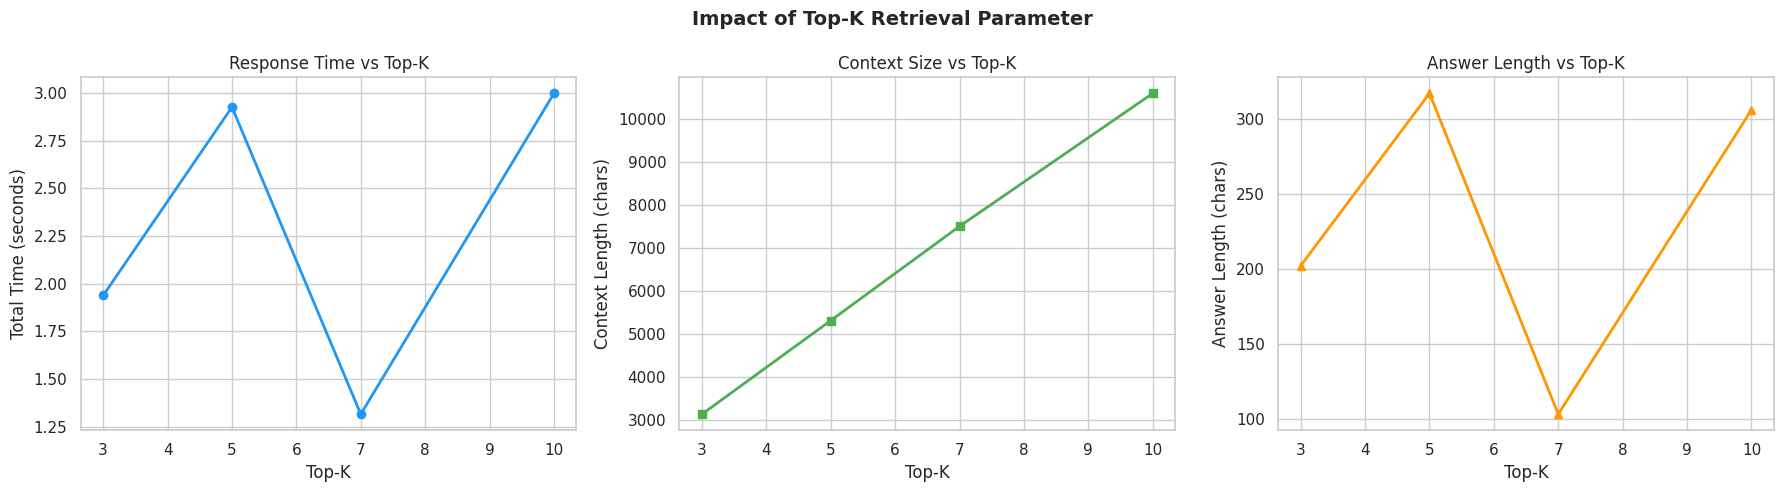

In [7]:
# Visualize top-K impact
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(topk_df['top_k'], topk_df['total_time'], 'o-', color='#2196F3', linewidth=2)
axes[0].set_xlabel('Top-K')
axes[0].set_ylabel('Total Time (seconds)')
axes[0].set_title('Response Time vs Top-K')

axes[1].plot(topk_df['top_k'], topk_df['context_length'], 's-', color='#4CAF50', linewidth=2)
axes[1].set_xlabel('Top-K')
axes[1].set_ylabel('Context Length (chars)')
axes[1].set_title('Context Size vs Top-K')

axes[2].plot(topk_df['top_k'], topk_df['answer_length'], '^-', color='#FF9800', linewidth=2)
axes[2].set_xlabel('Top-K')
axes[2].set_ylabel('Answer Length (chars)')
axes[2].set_title('Answer Length vs Top-K')

plt.suptitle('Impact of Top-K Retrieval Parameter', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(FIGURES_DIR / 'topk_impact.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4.5 Batch Processing

Process all ground truth questions through the RAG pipeline.

In [8]:
# Load ground truth questions
with open(GROUND_TRUTH_DIR / 'qa_pairs.json', 'r') as f:
    qa_pairs = json.load(f)

all_questions = [pair['question'] for pair in qa_pairs]
print(f"Processing {len(all_questions)} questions through RAG + baseline...")

# Run batch processing
batch_results = rag_pipeline.batch_answer(
    questions=all_questions,
    include_baseline=True,
    top_k=5,
)

print(f"\n✅ Batch processing complete: {len(batch_results)} results")

2026-04-09 12:27:43,533 - rag_qa_system - INFO - Processing question 1/51: What is Ireland's 2030 greenhouse gas emissions reduction ta...


Processing 51 questions through RAG + baseline...


2026-04-09 12:27:46,146 - httpx - INFO - HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"


2026-04-09 12:27:47,459 - httpx - INFO - HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"


2026-04-09 12:27:47,459 - rag_qa_system - INFO - Processing question 2/51: When must Ireland achieve climate neutrality?...


...

2026-04-09 12:34:40,049 - httpx - INFO - HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"


2026-04-09 12:34:40,050 - rag_qa_system - INFO - Processing question 51/51: What are Nearly Zero Energy Buildings (NZEB)?...


2026-04-09 12:34:42,944 - httpx - INFO - HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"


2026-04-09 12:34:47,963 - httpx - INFO - HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"



✅ Batch processing complete: 51 results


In [9]:
# Save batch results
rag_pipeline.save_results(batch_results, METRICS_DIR / 'rag_batch_results.json')

# Show sample results
for i, result in enumerate(batch_results[:3]):
    print(f"\n{'='*70}")
    print(f"Q{i+1}: {result['question']}")
    print(f"\nRAG Answer: {result['rag_answer'][:200]}...")
    print(f"Baseline Answer: {result.get('baseline_answer', 'N/A')[:200]}...")
    print(f"RAG Time: {result['rag_time']:.2f}s | Baseline Time: {result.get('baseline_time', 0):.2f}s")

2026-04-09 12:34:47,981 - rag_qa_system - INFO - Results saved to /home/umukesh/Desktop/dl/results/metrics/rag_batch_results.json



Q1: What is Ireland's 2030 greenhouse gas emissions reduction target?

RAG Answer: According to Source 4: climate-action-plan-2023-8b7dba92-f397-4163-8293-3aea656f6b5f.pdf, Ireland's EU Climate Targets state that under the EU Effort Sharing Regulation, Ireland is required to reduce ...
Baseline Answer: Ireland's 2030 greenhouse gas emissions reduction target is to reduce its net emissions by at least 70% compared to 1990 levels, as set out in the Climate Action and Clean Energy Act 2010....
RAG Time: 2.61s | Baseline Time: 1.31s

Q2: When must Ireland achieve climate neutrality?

RAG Answer: According to Source 4, Section 3 Chart data available from https://www.epa.ie/publications/monitoring--assessment/climate-change/air-emissions/GHG_, and specifically Source 5, Ireland's statutory nati...
Baseline Answer: Ireland is required to achieve climate neutrality by 2050, as set out in the Climate Action Plan 2017 and reinforced in the Programme for Government 2022. This means that all gree

## 4.6 Summary

✅ Built vector store with document embeddings  
✅ Created and tested RAG pipeline  
✅ Experimented with top-K retrieval parameter  
✅ Processed all questions through RAG + baseline  
✅ Saved batch results for evaluation  

**Next**: Notebook 05 — Baseline LLM (detailed baseline analysis)